# 🏀 March Machine Learning Mania 2026 — ADK Starter

**Build an AI Agent Pipeline for March Madness Predictions using Google's Agent Development Kit (ADK)!**

This notebook demonstrates how to use [Google ADK](https://google.github.io/adk-docs/) to orchestrate a March Madness prediction pipeline with specialized agents. Each agent handles one stage — data loading, feature engineering, model training, or submission generation — coordinated through ADK's `SequentialAgent`.

### What is ADK?
[Agent Development Kit](https://github.com/google/adk-python) is Google's open-source framework for building AI agents. You define **tools** (Python functions), wire them to **LLM-powered agents**, and orchestrate multi-agent workflows using patterns like `SequentialAgent`, `ParallelAgent`, and `LoopAgent`.

### Pipeline Overview
```
┌─────────────┐    ┌──────────────────┐    ┌──────────────┐    ┌────────────────┐
│  Data Loader │───▶│ Feature Engineer │───▶│ Model Trainer│───▶│ Submission Gen │
│    Agent     │    │     Agent        │    │    Agent     │    │     Agent      │
└─────────────┘    └──────────────────┘    └──────────────┘    └────────────────┘
     load_data()      compute_elo()          train_model()    generate_submission()
```

The baseline model is intentionally simple (**Elo + seed → logistic regression**). The focus is on the **agentic architecture** — you're encouraged to improve the model!

> **Tip:** You need a [Gemini API key](https://aistudio.google.com/apikey). Add it as a Kaggle secret named `GOOGLE_API_KEY`.

## 1. Setup & Installation

In [1]:
%%capture
!pip3 install google-adk>=1.0.0 scikit-learn pandas numpy

In [ ]:
import os, warnings
from dotenv import load_dotenv
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

load_dotenv()

print('✅ All imports successful')

In [ ]:
# ── Configuration ──
DATA_DIR = './data'
CURRENT_SEASON = 2026

# Elo hyperparameters — tune these!
ELO_K = 32       # K-factor: how much each game shifts ratings
ELO_INIT = 1500  # Starting Elo for all teams
ELO_HCA = 100    # Home court advantage in Elo points

# Global state (populated by tools, shared across agents via output_key)
DATA = {}    # loaded dataframes
ELO = {}     # (season, team_id) -> elo rating
MODEL_M = None  # trained sklearn pipeline for men's
MODEL_W = None  # trained sklearn pipeline for women's

## 2. Define Tools (Python Functions)

In ADK, **tools** are plain Python functions with descriptive docstrings. The LLM reads the docstring to understand when and how to call each tool. Our tools do the actual computation — the agents orchestrate them.

> **Key ADK concept:** Tools return `dict` results that the agent can interpret and relay. The agent's `output_key` saves its summary to the shared session state, so the next agent in the pipeline can reference it.

In [4]:
# ════════════════════════════════════════════════════════════════
# TOOL 1: Load competition data
# ════════════════════════════════════════════════════════════════

def load_competition_data() -> dict:
    """Load all March Madness competition CSV files and return a summary.

    Reads men's and women's team info, regular season results,
    tournament results, tournament seeds, the sample submission file,
    and Massey Ordinals rankings.

    Returns:
        dict: Summary with status, dataset sizes, and a message.
    """
    DATA['m_teams'] = pd.read_csv(f'{DATA_DIR}/MTeams.csv')
    DATA['w_teams'] = pd.read_csv(f'{DATA_DIR}/WTeams.csv')
    DATA['m_regular'] = pd.read_csv(f'{DATA_DIR}/MRegularSeasonCompactResults.csv')
    DATA['w_regular'] = pd.read_csv(f'{DATA_DIR}/WRegularSeasonCompactResults.csv')
    DATA['m_tourney'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')
    DATA['w_tourney'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneyCompactResults.csv')
    DATA['m_seeds'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')
    DATA['w_seeds'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneySeeds.csv')
    DATA['sample_sub'] = pd.read_csv(f'{DATA_DIR}/SampleSubmissionStage1.csv')
    DATA['massey'] = pd.read_csv(f'{DATA_DIR}/MMasseyOrdinals.csv')

    return {
        'status': 'success',
        'seasons': f"{DATA['m_regular']['Season'].min()}-{DATA['m_regular']['Season'].max()}",
        'mens_teams': len(DATA['m_teams']),
        'womens_teams': len(DATA['w_teams']),
        'regular_season_games': len(DATA['m_regular']) + len(DATA['w_regular']),
        'tourney_games': len(DATA['m_tourney']) + len(DATA['w_tourney']),
        'submission_rows': len(DATA['sample_sub']),
        'massey_systems': DATA['massey']['SystemName'].nunique(),
        'message': 'All data loaded successfully. Ready for feature engineering.'
    }

print("✅ Tool 1 defined: load_competition_data")

✅ Tool 1 defined: load_competition_data


In [5]:
# ════════════════════════════════════════════════════════════════
# TOOL 2: Compute Elo ratings
# ════════════════════════════════════════════════════════════════

def compute_elo_ratings() -> dict:
    """Compute Elo ratings for all men's and women's teams across all seasons.

    Uses a standard Elo system with K-factor, home court advantage,
    and between-season regression toward the mean.

    Returns:
        dict: Summary with top-rated teams and total ratings computed.
    """
    def _run_elo(regular_df, tourney_df):
        elo = {}
        season_elos = {}
        all_games = pd.concat([regular_df, tourney_df]).sort_values(['Season', 'DayNum'])
        prev_season = None

        for _, row in all_games.iterrows():
            season = row['Season']
            if season != prev_season and prev_season is not None:
                for tid, r in elo.items():
                    season_elos[(prev_season, tid)] = r
                elo = {tid: 0.75 * r + 0.25 * ELO_INIT for tid, r in elo.items()}
            prev_season = season

            w_id, l_id = row['WTeamID'], row['LTeamID']
            w_elo = elo.get(w_id, ELO_INIT)
            l_elo = elo.get(l_id, ELO_INIT)

            # Home court adjustment
            w_loc = row.get('WLoc', 'N')
            w_adj = w_elo + (ELO_HCA if w_loc == 'H' else (-ELO_HCA if w_loc == 'A' else 0))

            # Expected win probability & update
            exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_adj) / 400.0))
            elo[w_id] = w_elo + ELO_K * (1.0 - exp_w)
            elo[l_id] = l_elo + ELO_K * (0.0 - (1.0 - exp_w))

        if prev_season:
            for tid, r in elo.items():
                season_elos[(prev_season, tid)] = r
        return season_elos

    m_elos = _run_elo(DATA['m_regular'], DATA['m_tourney'])
    w_elos = _run_elo(DATA['w_regular'], DATA['w_tourney'])
    ELO.update(m_elos)
    ELO.update(w_elos)

    # Top teams for display
    m_names = dict(zip(DATA['m_teams']['TeamID'], DATA['m_teams']['TeamName']))
    w_names = dict(zip(DATA['w_teams']['TeamID'], DATA['w_teams']['TeamName']))
    latest_m = max(s for s, _ in m_elos.keys())
    latest_w = max(s for s, _ in w_elos.keys())
    top_m = sorted([(tid, r) for (s, tid), r in m_elos.items() if s == latest_m], key=lambda x: -x[1])[:5]
    top_w = sorted([(tid, r) for (s, tid), r in w_elos.items() if s == latest_w], key=lambda x: -x[1])[:5]

    return {
        'status': 'success',
        'total_ratings': len(ELO),
        'top_mens': [f"{m_names.get(t, t)}: {r:.0f}" for t, r in top_m],
        'top_womens': [f"{w_names.get(t, t)}: {r:.0f}" for t, r in top_w],
        'message': f'Elo computed through {latest_m} (men) and {latest_w} (women).'
    }

print("✅ Tool 2 defined: compute_elo_ratings")

✅ Tool 2 defined: compute_elo_ratings


In [ ]:
# ════════════════════════════════════════════════════════════════
# TOOL 3: Train prediction model
# ════════════════════════════════════════════════════════════════

def _parse_seed(seed_str):
    """Extract numeric seed from string like 'W01', 'X16a' → 1, 16."""
    return int(seed_str[1:3])


def _build_massey_map(system='POM'):
    """Build (season, team_id) -> ordinal rank using the latest pre-tournament ranking."""
    massey = DATA['massey']
    pom = massey[massey['SystemName'] == system].copy()
    pom = pom.sort_values('RankingDayNum')
    pom = pom.groupby(['Season', 'TeamID']).last().reset_index()
    return {(row['Season'], row['TeamID']): row['OrdinalRank']
            for _, row in pom.iterrows()}


def _build_features(t_df, seed_map, pom_map, use_pom=True):
    """Build feature matrix and labels from a tournament results dataframe."""
    median_pom_rank = 175
    X, y = [], []
    for _, row in t_df.iterrows():
        season = row['Season']
        if season < 2003:
            continue

        w_id, l_id = row['WTeamID'], row['LTeamID']
        w_elo = ELO.get((season - 1, w_id), ELO_INIT)
        l_elo = ELO.get((season - 1, l_id), ELO_INIT)
        w_seed = seed_map.get((season, w_id), 8)
        l_seed = seed_map.get((season, l_id), 8)

        if use_pom:
            w_pom = pom_map.get((season, w_id), median_pom_rank)
            l_pom = pom_map.get((season, l_id), median_pom_rank)

        if w_id < l_id:
            feats = [w_elo - l_elo, l_seed - w_seed]
            if use_pom:
                feats.append(w_pom - l_pom)
            X.append(feats)
            y.append(1)
        else:
            feats = [l_elo - w_elo, w_seed - l_seed]
            if use_pom:
                feats.append(l_pom - w_pom)
            X.append(feats)
            y.append(0)
    return np.array(X), np.array(y)


def train_prediction_model() -> dict:
    """Train separate logistic regression pipelines for men's and women's.

    Men's model features: [elo_diff, seed_diff, pom_diff] (KenPom included).
    Women's model features: [elo_diff, seed_diff] (no Massey Ordinals for women).
    Both use StandardScaler + LogisticRegression to handle feature scale differences.
    Evaluates each with 5-fold cross-validation Brier score.

    Returns:
        dict: Summary with training sizes and Brier scores for both models.
    """
    global MODEL_M, MODEL_W

    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    pom_map = _build_massey_map('POM')

    # Men's: 3 features (elo_diff, seed_diff, pom_diff)
    X_m, y_m = _build_features(DATA['m_tourney'], seed_map, pom_map, use_pom=True)
    # Women's: 2 features (elo_diff, seed_diff) — no POM coverage
    X_w, y_w = _build_features(DATA['w_tourney'], seed_map, pom_map, use_pom=False)

    clf = lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, solver='lbfgs'))

    MODEL_M = clf()
    MODEL_M.fit(X_m, y_m)
    brier_m = -cross_val_score(clf(), X_m, y_m, scoring='neg_brier_score', cv=5).mean()

    MODEL_W = clf()
    MODEL_W.fit(X_w, y_w)
    brier_w = -cross_val_score(clf(), X_w, y_w, scoring='neg_brier_score', cv=5).mean()

    lr_m = MODEL_M.named_steps['logisticregression']
    lr_w = MODEL_W.named_steps['logisticregression']

    return {
        'status': 'success',
        'mens_training_games': len(y_m),
        'womens_training_games': len(y_w),
        'mens_cv_brier': f"{brier_m:.4f}",
        'womens_cv_brier': f"{brier_w:.4f}",
        'mens_coefficients': {
            'elo_diff':  f"{lr_m.coef_[0][0]:.6f}",
            'seed_diff': f"{lr_m.coef_[0][1]:.6f}",
            'pom_diff':  f"{lr_m.coef_[0][2]:.6f}",
        },
        'womens_coefficients': {
            'elo_diff':  f"{lr_w.coef_[0][0]:.6f}",
            'seed_diff': f"{lr_w.coef_[0][1]:.6f}",
        },
        'message': f"Men's CV Brier: {brier_m:.4f} | Women's CV Brier: {brier_w:.4f}"
    }

print("✅ Tool 3 defined: train_prediction_model")

In [ ]:
# ════════════════════════════════════════════════════════════════
# TOOL 4: Generate submission file
# ════════════════════════════════════════════════════════════════

# Men's TeamIDs for routing predictions to the correct model
def _get_mens_team_ids():
    return set(DATA['m_teams']['TeamID'].tolist())


def generate_submission() -> dict:
    """Generate predictions for every possible matchup and save submission.csv.

    Routes each matchup to the correct model (men's or women's) based on TeamID.
    Men's: [elo_diff, seed_diff, pom_diff]. Women's: [elo_diff, seed_diff].

    Returns:
        dict: Summary with number of predictions and output path.
    """
    sub = DATA['sample_sub'].copy()

    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    pom_map = _build_massey_map('POM')
    median_pom_rank = 175
    mens_ids = _get_mens_team_ids()

    preds = []
    for _, row in sub.iterrows():
        parts = row['ID'].split('_')
        season = int(parts[0])
        t1, t2 = int(parts[1]), int(parts[2])

        e1 = ELO.get((season - 1, t1), ELO_INIT)
        e2 = ELO.get((season - 1, t2), ELO_INIT)
        s1 = seed_map.get((season, t1), 8)
        s2 = seed_map.get((season, t2), 8)

        is_mens = t1 in mens_ids
        if is_mens:
            p1 = pom_map.get((season, t1), median_pom_rank)
            p2 = pom_map.get((season, t2), median_pom_rank)
            features = np.array([[e1 - e2, s2 - s1, p1 - p2]])
            prob = MODEL_M.predict_proba(features)[0][1]
        else:
            features = np.array([[e1 - e2, s2 - s1]])
            prob = MODEL_W.predict_proba(features)[0][1]

        preds.append(np.clip(prob, 0.01, 0.99))

    sub['Pred'] = preds
    output_path = './output/submission.csv'
    sub.to_csv(output_path, index=False)

    return {
        'status': 'success',
        'num_predictions': len(preds),
        'mean_pred': f"{np.mean(preds):.4f}",
        'std_pred': f"{np.std(preds):.4f}",
        'output_path': output_path,
        'message': f'Submission saved to {output_path} with {len(preds)} predictions.'
    }

print("✅ Tool 4 defined: generate_submission")

## 3. Run the Pipeline

In [ ]:
def run_pipeline():
    print("🚀 Starting pipeline...\n")

    print("[1/4] Loading data...")
    result = load_competition_data()
    print(f"      ✅ {result['message']}")

    print("[2/4] Computing Elo ratings...")
    result = compute_elo_ratings()
    print(f"      ✅ {result['message']}")

    print("[3/4] Training models...")
    result = train_prediction_model()
    print(f"      ✅ {result['message']}")
    print(f"      Men's coefficients:   elo={result['mens_coefficients']['elo_diff']}, "
          f"seed={result['mens_coefficients']['seed_diff']}, "
          f"pom={result['mens_coefficients']['pom_diff']}")
    print(f"      Women's coefficients: elo={result['womens_coefficients']['elo_diff']}, "
          f"seed={result['womens_coefficients']['seed_diff']}")

    print("[4/4] Generating submission...")
    result = generate_submission()
    print(f"      ✅ {result['message']}")

    print("\n✅ Pipeline complete!")

run_pipeline()

## 5. Verify Submission

In [10]:
# ── Check the output ──
sub = pd.read_csv('./output/submission.csv')
print(f"Submission shape: {sub.shape}")
print(f"Prediction range: [{sub['Pred'].min():.4f}, {sub['Pred'].max():.4f}]")
print(f"Mean prediction:  {sub['Pred'].mean():.4f}")
print(f"Std prediction:   {sub['Pred'].std():.4f}")
print()
print(sub.head(10))

Submission shape: (519144, 2)
Prediction range: [0.0118, 0.9893]
Mean prediction:  0.5082
Std prediction:   0.1657

               ID      Pred
0  2022_1101_1102  0.680622
1  2022_1101_1103  0.724890
2  2022_1101_1104  0.389389
3  2022_1101_1105  0.667103
4  2022_1101_1106  0.699147
5  2022_1101_1107  0.601283
6  2022_1101_1108  0.659572
7  2022_1101_1110  0.546468
8  2022_1101_1111  0.578941
9  2022_1101_1112  0.299067


In [11]:
!pip3 install matplotlib

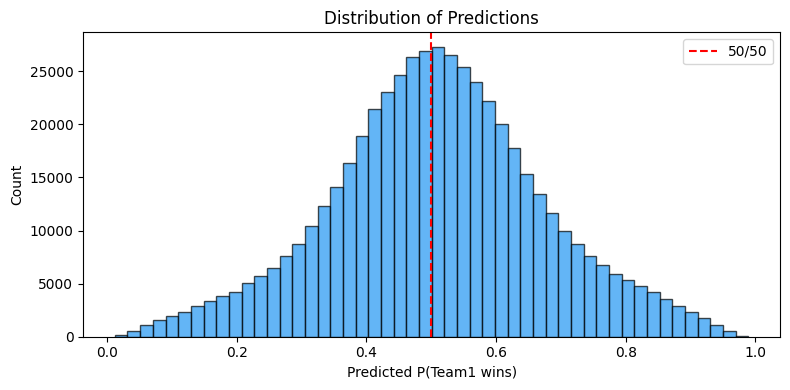

In [12]:
# ── Quick sanity check: distribution of predictions ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
ax.axvline(0.5, color='red', linestyle='--', label='50/50')
ax.set_xlabel('Predicted P(Team1 wins)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predictions')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Ideas to Improve This Baseline

This starter gets you a valid submission, but there's lots of room to improve. Here are some directions:

### Better Features
- **Detailed box scores**: Use `MRegularSeasonDetailedResults.csv` for shooting %, rebounds, turnovers, etc.
- **Strength of schedule**: Weight Elo updates by opponent strength
- **Massey Ordinals**: The `MMasseyOrdinals.csv` file has rankings from 100+ systems (Sagarin, Pomeroy, RPI, etc.)
- **Recency weighting**: Give more weight to late-season games
- **Conference strength**: Compute conference-level Elo or use conference tournament results

### Better Models
- **Gradient boosting** (XGBoost, LightGBM) with more features
- **Ensemble** multiple models (Elo-based, seed-based, stats-based)
- **Neural nets** for learning complex feature interactions

### More Agents
- **`ParallelAgent`**: Compute men's and women's features simultaneously
- **`LoopAgent`**: Iterate on hyperparameter tuning (K-factor, home court advantage)
- **Analysis Agent**: Add an agent that explores the data and suggests features
- **Validation Agent**: An agent that checks predictions against historical tournament results

### ADK Patterns to Explore
```python
from google.adk.agents.parallel_agent import ParallelAgent
from google.adk.agents.loop_agent import LoopAgent

# Parallel feature computation
parallel_features = ParallelAgent(
    name="ParallelFeatures",
    sub_agents=[mens_elo_agent, womens_elo_agent, stats_agent]
)

# Iterative tuning
tuning_loop = LoopAgent(
    name="HyperparamTuner",
    sub_agents=[train_agent, evaluate_agent, adjust_agent],
    max_iterations=5
)
```

Good luck and happy forecasting! 🏀